In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120 

try:
    df = pd.read_csv('resultados_aps_mochila.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'resultados_aps_mochila.csv' não foi encontrado na pasta atual.")
    df = None

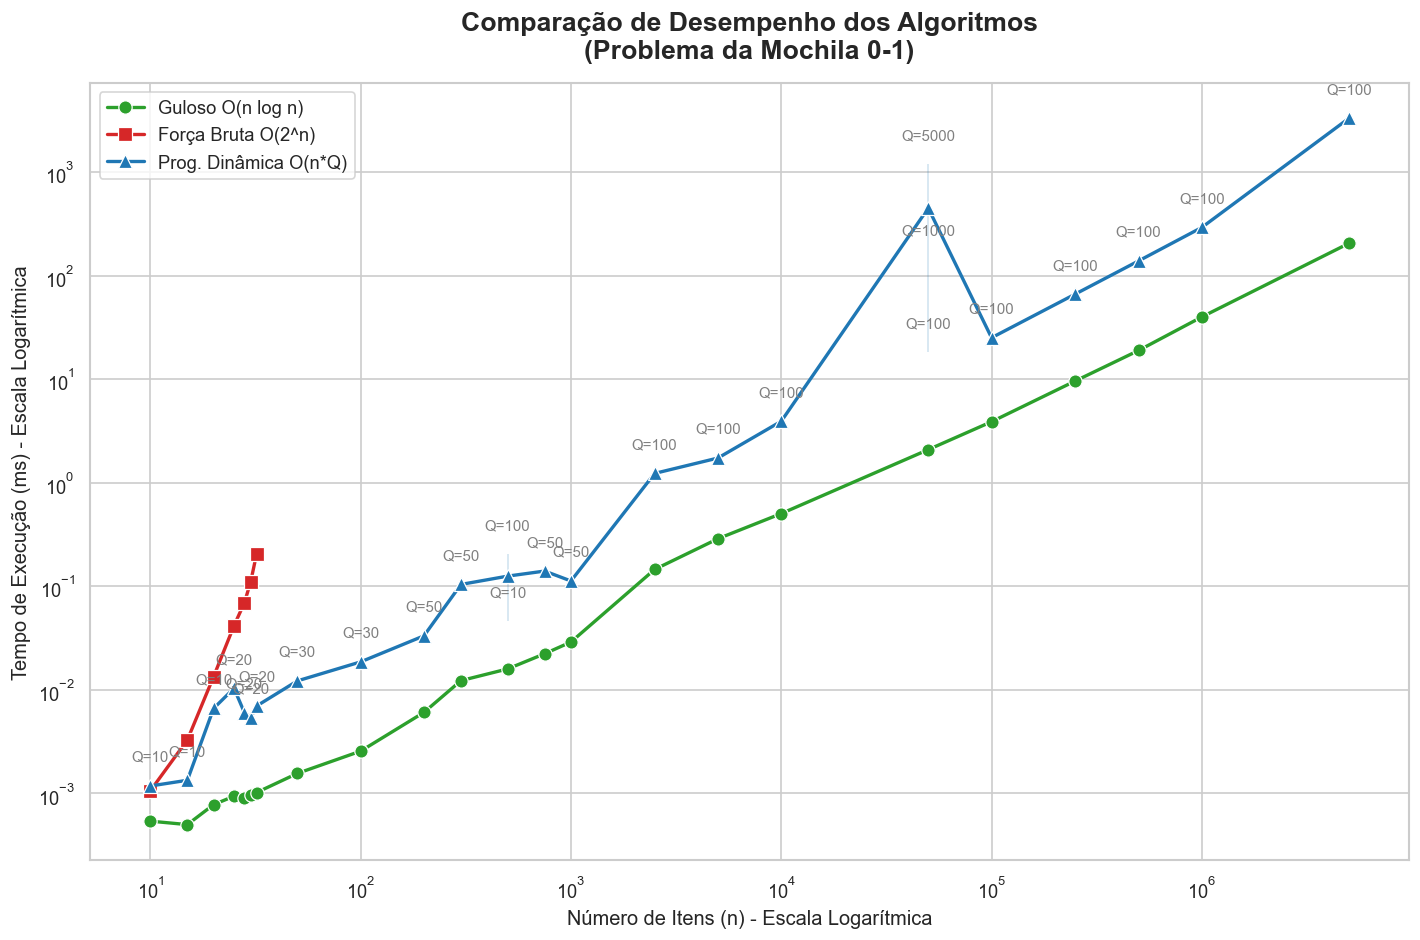

,n,Q,Guloso (ms),Força Bruta (ms),DP (ms)
0,10,10,0.00054,0.00106,0.00118
1,15,10,0.00050,0.00328,0.00134
2,20,10,0.00078,0.01344,0.00662
3,25,20,0.00094,0.04166,0.01036
4,28,20,0.00090,0.06914,0.00604
5,30,20,0.00096,0.11038,0.00538
6,32,20,0.00102,0.20442,0.00698
7,50,30,0.00156,Abortado (>50),0.01220
8,100,30,0.00256,Abortado (>50),0.01862
9,200,50,0.00606,Abortado (>50),0.03322


In [ ]:


if df is not None:
    df['greedy_ms'] = df['greedy_ns_avg'] / 1_000_000
    df['bf_ms'] = df['bruteforce_ns_avg'] / 1_000_000
    df['dp_ms'] = df['dp_ns_avg'] / 1_000_000

    df['bf_ms'] = df['bf_ms'].apply(lambda x: np.nan if x <= 0 else x)

    plt.figure(figsize=(12, 8))

    
    sns.lineplot(data=df, x='n', y='greedy_ms', marker='o', 
                 color='#2ca02c', linewidth=2, markersize=8, label='Guloso O(n log n)')
    
    sns.lineplot(data=df.dropna(subset=['bf_ms']), x='n', y='bf_ms', marker='s', 
                 color='#d62728', linewidth=2, markersize=8, label='Força Bruta O(2^n)')
                 
    sns.lineplot(data=df, x='n', y='dp_ms', marker='^', 
                 color='#1f77b4', linewidth=2, markersize=8, label='Prog. Dinâmica O(n*Q)')

    plt.xscale('log')
    plt.yscale('log')

    plt.title('Comparação de Desempenho dos Algoritmos\n(Problema da Mochila 0-1)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Número de Itens (n) - Escala Logarítmica', fontsize=12)
    plt.ylabel('Tempo de Execução (ms) - Escala Logarítmica', fontsize=12)

    for i in range(df.shape[0]):
        plt.annotate(
            f"Q={df['Q'].iloc[i]}", 
            (df['n'].iloc[i], df['dp_ms'].iloc[i]),
            textcoords="offset points", 
            xytext=(0, 15), 
            ha='center',
            fontsize=9,
            color='gray'
        )

    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    
    plt.show()
    
    cols = ['n', 'Q', 'greedy_ms', 'bf_ms', 'dp_ms']
    final_df = df[cols].rename(columns={
        'greedy_ms': 'Guloso (ms)',
        'bf_ms': 'Força Bruta (ms)',
        'dp_ms': 'DP (ms)'
    })
    
    final_df['Força Bruta (ms)'] = final_df['Força Bruta (ms)'].fillna('Abortado (>50)')
    
    display(final_df)